In [2]:
from mfpy.utils import label_series
from mfpy.clustering import SegmentBasedCluster
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

filename = "../../../data/ADP/A_2D_1ps.dat"
data = np.loadtxt(filename)
data = (data + 180) / 360

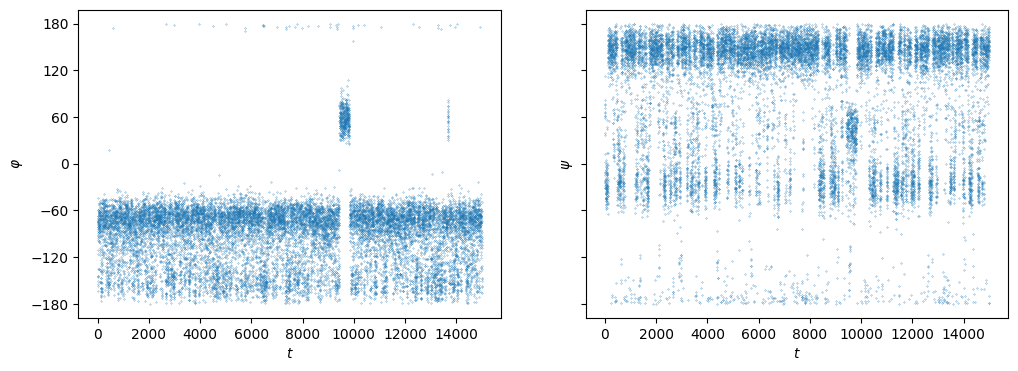

In [27]:
# T = data.shape[0]
l = 0
u = 15000
s = .05
x = data[l:u, :]
h=4
fig, ax = plt.subplots(1,2, figsize=(3*h,h), sharey=True)
ax[0].scatter(range((u-l)), 360*x[:,0]-180, s=s, rasterized=True)
ax[1].scatter(range((u-l)), 360*x[:,1]-180, s=s, rasterized=True)
ax[0].set_ylabel(r"$\varphi$")
ax[1].set_ylabel(r"$\psi$")
ax[0].set_xlabel(r"$t$")
ax[1].set_xlabel(r"$t$")
ticks = [-180, -120, -60, 0, 60, 120, 180]
ax[0].set_yticks(ticks)
plt.savefig("adp-angles.pdf", bbox_inches="tight")

In [4]:
data_subset = data[l:u, :]
w = np.array([10, 10])
q = np.array([0.65, 0.85])
sbc = SegmentBasedCluster(w, q, periodic=True)

sbc.fit(data_subset)

  1%|▎                                     | 6725/1003236 [00:16<35:42, 465.15it/s]/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/ot/lp/solver_1d.py:796: RuntimeWarning: divide by zero encountered in divide
  (Ctp - Ctm + tm * dCptm - tp * dCmtp) / (dCptm - dCmtp)
100%|███████████████████████████████████| 1003236/1003236 [58:20<00:00, 286.59it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(
100%|█████████████████████████████████████| 117370/117370 [15:38<00:00, 125.02it/s]


SegmentBasedCluster(periodic=True, quantile=array([0.65, 0.85]),
                    window_size=array([10, 10]))

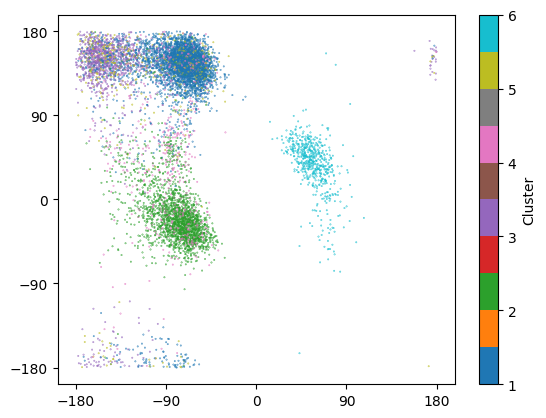

In [6]:
data_scaled = data_subset * 360 - 180
labels = sbc.point_labels_
N = 6  # Choose number of clusters to plot
unique_labels, counts = np.unique(labels, return_counts=True)
top_labels = unique_labels[np.argsort(counts)[-N:]][::-1]
mask = np.isin(labels, top_labels)
fig = plt.figure()
ticks = [-180, -90, 0, 90, 180]
ax = fig.add_subplot()
scatter = ax.scatter(data_scaled[mask, 0], data_scaled[mask, 1],
                     c=labels[mask], cmap='tab10',s=.1, rasterized=True)
plt.colorbar(scatter, label='Cluster')
ax.set_xticks(ticks)
ax.set_yticks(ticks)
plt.savefig("adp-clusters.pdf", bbox_inches="tight")
plt.show()

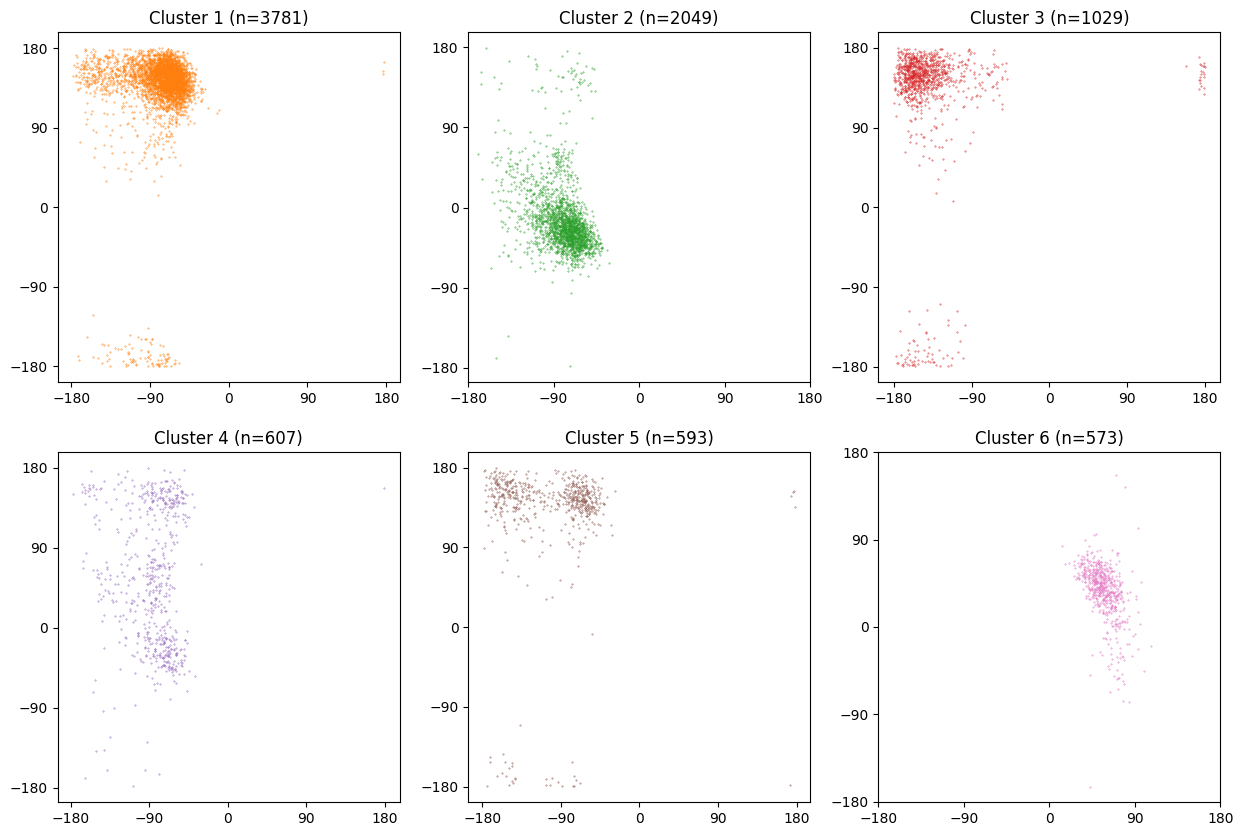

In [5]:
labels = sbc.point_labels_
unique_labels, counts = np.unique(labels, return_counts=True)
top_labels = unique_labels[np.argsort(counts)[-N:]][::-1]
cmap = plt.cm.tab10
cols = 3
rows = int(np.ceil(N / cols))
fig = plt.figure(figsize=(5*cols, 5*rows))


for i, label in enumerate(top_labels):
    ax = fig.add_subplot(rows, cols, i+1)
    mask = labels == label
    ax.scatter(data_scaled[mask, 0], data_scaled[mask, 1],
               c=[cmap(label)], s=.1, rasterized=True)
    ax.set_title(f'Cluster {label} (n={np.sum(mask)})')
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
plt.savefig("adp-top-individual-clusters.pdf", bbox_inches="tight")
plt.show()

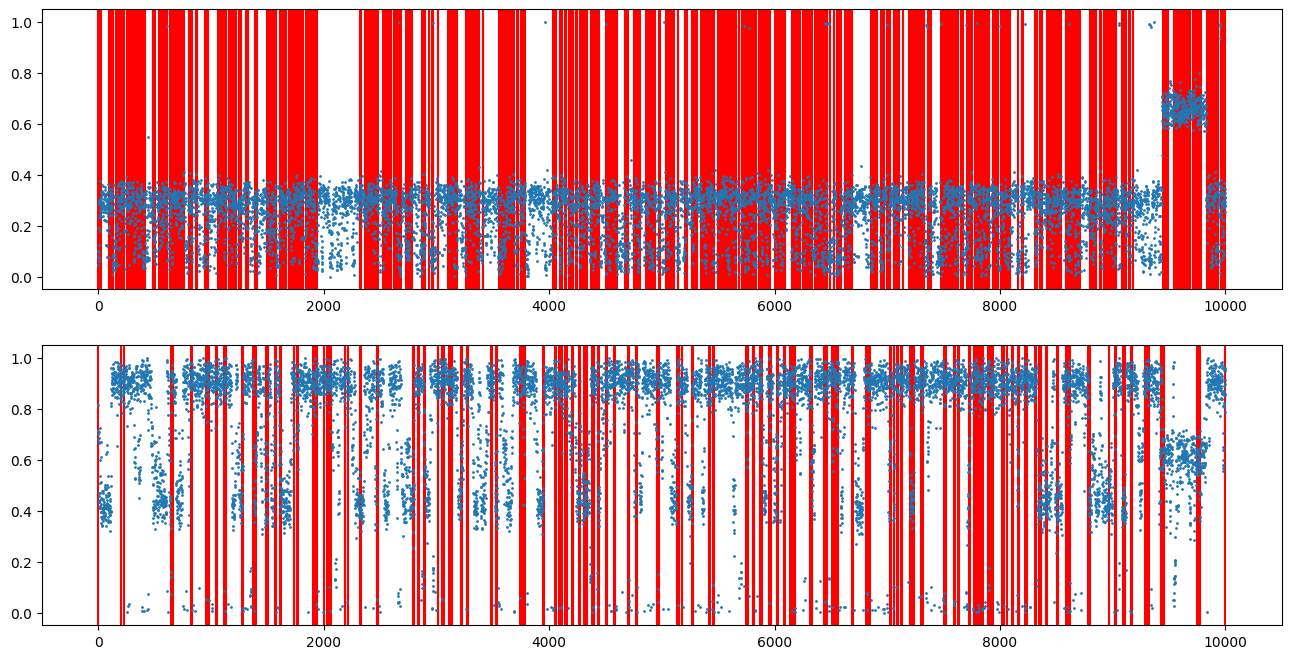

In [16]:
phi_cps = np.where(sbc.change_points_[:,0] == 1)[0]
psi_cps = np.where(sbc.change_points_[:,1] == 1)[0]

fig, ax = plt.subplots(2,1, figsize=(16,8))
T = 10000
ax[0].scatter(range(T), data[:10000,0], s=1, rasterized=True)
ax[1].scatter(range(T), data[:10000,1], s=1, rasterized=True)

for cp in phi_cps:
    ax[0].axvline(cp, color='red', zorder=0)
for cp in psi_cps:
    ax[1].axvline(cp, color='red', zorder=0)